# Weak-Scaling Decode Figures

This notebook rebuilds the presentation figures from the weak-scaling run:

- `profiling_results/llama_p_weak_sweep_real.zip`
- configs: `llama8B_weak_1_240`, `llama8B_weak_1_360`, `llama8B_weak_1_480`

The `weak` configs are derived from the repository's existing `llama8B_4k_1_480` anchor. They keep local work fixed (`dim/P=9`, `seq_len/P=9`, `ffn_dim/P=30`, `P/group_num=24`) while scaling global problem size with `P`.

This notebook keeps the plots inline, in the style of `communication_analysis.ipynb`. The Figure 1 section is extended with:

1. total-time breakdown into compute, communication, elementwise/norm, KV-cache GEMV, and other
2. per-phase computation-intensity and 48 KB local-SRAM fit checks

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/waferllm-mplconfig")
os.environ.setdefault("IPYTHONDIR", "/tmp/waferllm-ipython")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["IPYTHONDIR"]).mkdir(parents=True, exist_ok=True)

import json
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#C7CDD8",
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
})

ZIP_PATH = Path("profiling_results/llama_p_weak_sweep_real.zip")
SRAM_BYTES = 48 * 1024
F16_BYTES = 2
ZIP_PATH

PosixPath('profiling_results/llama_p_weak_sweep_real.zip')

In [2]:
PHASE_NAMES = [
    "rmsnorm_x_local", "rmsnorm_x_comm", "qkv_local", "qkv_comm",
    "rope", "score_local", "score_comm", "softmax_local", "softmax_comm",
    "output_local", "output_comm", "o_local", "o_comm", "attn_residual",
    "rmsnorm_z_local", "rmsnorm_z_comm", "upgate_local", "upgate_comm",
    "silu_mul", "down_local", "down_comm", "ffn_residual",
]

PHASE_GROUPS = {
    "RMSNorm+QKV": ["rmsnorm_x_comm", "rmsnorm_x_local", "qkv_comm", "qkv_local"],
    "RoPE+Score": ["rope", "score_comm", "score_local"],
    "Softmax+Output": ["softmax_comm", "softmax_local", "output_comm", "output_local"],
    "O+Residual": ["o_comm", "o_local", "attn_residual"],
    "RMSNorm+FFN": [
        "rmsnorm_z_comm", "rmsnorm_z_local", "upgate_comm", "upgate_local",
        "silu_mul", "down_comm", "down_local", "ffn_residual",
    ],
}

LOCAL_PHASE_GROUPS = [
    ("RMSNorm+QKV", ["rmsnorm_x_local", "qkv_local"]),
    ("RoPE+Score", ["rope", "score_local"]),
    ("Softmax+Output", ["softmax_local", "output_local"]),
    ("O+Residual", ["o_local", "attn_residual"]),
    ("RMSNorm+FFN", ["rmsnorm_z_local", "upgate_local", "silu_mul", "down_local", "ffn_residual"]),
]
PHASE_TO_GROUP = {phase: group for group, phases in LOCAL_PHASE_GROUPS for phase in phases}

PHASE_GROUP_CATEGORY = {
    "RMSNorm+QKV": {"Communication": ["rmsnorm_x_comm", "qkv_comm"], "Compute (Dist-GEMV)": ["qkv_local"], "Elementwise/Norm": ["rmsnorm_x_local"], "KV-cache GEMV": []},
    "RoPE+Score": {"Communication": ["score_comm"], "Compute (Dist-GEMV)": [], "Elementwise/Norm": ["rope"], "KV-cache GEMV": ["score_local"]},
    "Softmax+Output": {"Communication": ["softmax_comm", "output_comm"], "Compute (Dist-GEMV)": [], "Elementwise/Norm": ["softmax_local"], "KV-cache GEMV": ["output_local"]},
    "O+Residual": {"Communication": ["o_comm"], "Compute (Dist-GEMV)": ["o_local"], "Elementwise/Norm": ["attn_residual"], "KV-cache GEMV": []},
    "RMSNorm+FFN": {"Communication": ["rmsnorm_z_comm", "upgate_comm", "down_comm"], "Compute (Dist-GEMV)": ["upgate_local", "down_local"], "Elementwise/Norm": ["rmsnorm_z_local", "silu_mul", "ffn_residual"], "KV-cache GEMV": []},
}

COMM_PHASES = {
    "rmsnorm_x_comm": {"label": "RMSNorm-X comm", "axis": "Y-axis", "api_impl": "all_reduce_bsz", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz"},
    "qkv_comm": {"label": "QKV comm", "axis": "Y-axis", "api_impl": "all_reduce_bsz_dim_QKV_fusion", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz*3*dim_p_pe"},
    "score_comm": {"label": "Score comm", "axis": "X-axis", "api_impl": "all_reduce_bsz_seq_len", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz*seq_len_p_pe"},
    "softmax_comm": {"label": "Softmax comm", "axis": "Y-axis", "api_impl": "all_reduceMax_bsz + all_reduce_bsz", "reduction": "max + sum", "all_reduce_ops": 2, "broadcast_ops": 2, "payload": "2*bsz"},
    "output_comm": {"label": "Output comm", "axis": "Y-axis", "api_impl": "all_reduce_bsz_dim", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz*dim_p_pe"},
    "o_comm": {"label": "O-proj comm", "axis": "X-axis", "api_impl": "all_reduce_bsz_dim", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz*dim_p_pe"},
    "rmsnorm_z_comm": {"label": "RMSNorm-Z comm", "axis": "Y-axis", "api_impl": "all_reduce_bsz", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz"},
    "upgate_comm": {"label": "Up/Gate comm", "axis": "Y-axis", "api_impl": "all_reduce_bsz_ffn_dim_ZZ_fusion", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz*2*ffn_dim_p_pe"},
    "down_comm": {"label": "Down comm", "axis": "X-axis", "api_impl": "all_reduce_bsz_dim", "reduction": "sum", "all_reduce_ops": 1, "broadcast_ops": 1, "payload": "bsz*dim_p_pe"},
}

CATEGORY_ORDER = ["Communication", "Compute (Dist-GEMV)", "Elementwise/Norm", "KV-cache GEMV", "Other"]
CATEGORY_COLORS = {"Communication": "#E68613", "Compute (Dist-GEMV)": "#2F66E0", "Elementwise/Norm": "#1A9A6D", "KV-cache GEMV": "#7C3AED", "Other": "#94A3B8"}
PHASE_GROUP_COLORS = {"RMSNorm+QKV": "#2F66E0", "RoPE+Score": "#1F8FB5", "Softmax+Output": "#7C3AED", "O+Residual": "#E68613", "RMSNorm+FFN": "#1A9A6D"}
PHASE_COLORS = {"RMSNorm-X comm": "#2F66E0", "QKV comm": "#4F7DF2", "Score comm": "#1F8FB5", "Softmax comm": "#7C3AED", "Output comm": "#9B5DE5", "O-proj comm": "#E68613", "RMSNorm-Z comm": "#E0A11B", "Up/Gate comm": "#1A9A6D", "Down comm": "#2CB67D"}
AXIS_COLORS = {"Y-axis": "#2F66E0", "X-axis": "#E68613"}

In [3]:
def load_json(zf, name):
    return json.loads(zf.read(name))

def payload_elements(expr, derived, config):
    bsz = config["bsz"]
    dim_p_pe = derived["dim_p_pe"]
    seq_len_p_pe = derived["seq_len_p_pe"]
    ffn_dim_p_pe = derived["ffn_dim_p_pe"]
    return {
        "bsz": bsz,
        "bsz*3*dim_p_pe": bsz * 3 * dim_p_pe,
        "bsz*seq_len_p_pe": bsz * seq_len_p_pe,
        "2*bsz": 2 * bsz,
        "bsz*dim_p_pe": bsz * dim_p_pe,
        "bsz*2*ffn_dim_p_pe": bsz * 2 * ffn_dim_p_pe,
    }[expr]

def local_phase_estimate(phase, derived, config):
    d = derived["dim_p_pe"]
    s = derived["seq_len_p_pe"]
    f = derived["ffn_dim_p_pe"]
    b = config["bsz"]
    elems = {
        "scalar": b, "dim": b * d, "seq": b * s, "ffn": b * f,
        "qkv": b * 3 * d, "zz": b * 2 * f,
        "dim_weight": d * d, "kv_cache": d * s, "ffn_weight": d * f,
    }
    estimates = {
        "rmsnorm_x_local": (4 * b * d, elems["dim"] * 4 + elems["scalar"]),
        "qkv_local": (6 * b * d * d, elems["dim"] * 2 + elems["qkv"] + 3 * elems["dim_weight"]),
        "rope": (6 * b * d, elems["qkv"] + 6 * d),
        "score_local": (2 * b * d * s + b * s, elems["dim"] + elems["kv_cache"] + elems["seq"]),
        "softmax_local": (4 * b * s, elems["seq"] * 2 + elems["scalar"] * 2),
        "output_local": (2 * b * s * d, elems["seq"] + elems["kv_cache"] + elems["dim"]),
        "o_local": (2 * b * d * d, elems["dim"] * 2 + elems["dim_weight"]),
        "attn_residual": (b * d, elems["dim"] * 3),
        "rmsnorm_z_local": (4 * b * d, elems["dim"] * 4 + elems["scalar"]),
        "upgate_local": (4 * b * d * f, elems["dim"] + elems["zz"] + 2 * elems["ffn_weight"]),
        "silu_mul": (5 * b * f, elems["ffn"] * 3),
        "down_local": (2 * b * f * d, elems["ffn"] + elems["ffn_weight"] + elems["dim"]),
        "ffn_residual": (b * d, elems["dim"] * 3),
    }
    if phase.endswith("_comm"):
        meta = COMM_PHASES[phase]
        payload = payload_elements(meta["payload"], derived, config)
        return 0, payload * F16_BYTES, "communication payload only"
    flops, resident_elems = estimates.get(phase, (0, 0))
    return int(flops), int(resident_elems * F16_BYTES), "local estimate from CSL loop/tensor shapes"

def stacked_bar(data, stacks, colors, *, title, ylabel, xlabel="Weak-scaling config", legend_anchor=(1.02, 1.0)):
    fig, ax = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
    x = np.arange(len(data.index))
    bottom = np.zeros(len(data.index), dtype=float)
    for col in stacks:
        values = data[col].to_numpy(dtype=float)
        ax.bar(x, values, bottom=bottom, width=0.62, label=col, color=colors[col], edgecolor="white", linewidth=0.9)
        bottom += values
    ax.set_xticks(x, data.index)
    ax.set_title(title, loc="left", pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.legend(loc="upper left", bbox_to_anchor=legend_anchor, fontsize=9)
    return fig, ax

def stacked_phase_group_panels(df, stacks, colors, config_order):
    fig, axes = plt.subplots(1, len(config_order), figsize=(16.5, 5.6), sharey=True, constrained_layout=True)
    if len(config_order) == 1:
        axes = [axes]
    for ax, config in zip(axes, config_order):
        panel = (
            df[df["config"] == config]
            .pivot(index="phase_group", columns="category", values="cycles")
            .reindex(index=list(PHASE_GROUPS), columns=stacks)
            .fillna(0)
        )
        x = np.arange(len(panel.index))
        bottom = np.zeros(len(panel.index), dtype=float)
        for col in stacks:
            values = panel[col].to_numpy(dtype=float)
            ax.bar(x, values, bottom=bottom, width=0.68, color=colors[col], edgecolor="white", linewidth=0.9, label=col)
            bottom += values
        ax.set_xticks(x, panel.index, rotation=25, ha="right")
        ax.set_title(config, fontsize=12, loc="left")
        ax.grid(axis="y", color="#CBD5E1", linewidth=0.8, alpha=0.6)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.tick_params(length=0)
        ax.set_xlabel("Phase group")
    axes[0].set_ylabel("Cycles")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.83, 0.98), fontsize=9, frameon=False)
    fig.suptitle("Weak P sweep: internal breakdown of each phase group", x=0.06, ha="left", fontsize=15, fontweight="semibold")
    return fig, axes

def phase_metric_panels(df):
    plot_df = df[[
        "phase",
        "estimated_intensity_flop_per_byte",
        "sram_utilization_pct",
        "fits_48KB_SRAM",
    ]].copy()
    plot_df["kind"] = np.where(plot_df["phase"].str.endswith("_comm"), "Communication", "Local compute/elementwise")
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))

    fig, axes = plt.subplots(1, 2, figsize=(14, 8.8), sharey=True, constrained_layout=True)
    colors = plot_df["kind"].map({"Communication": "#E68613", "Local compute/elementwise": "#2F66E0"})

    axes[0].barh(y, plot_df["estimated_intensity_flop_per_byte"], color=colors, edgecolor="white", linewidth=0.8)
    axes[0].set_title("Per-phase computation intensity", loc="left", pad=10)
    axes[0].set_xlabel("Estimated FLOP-equivalent per byte")
    axes[0].set_yticks(y, plot_df["phase"])
    axes[0].grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    axes[0].grid(axis="y", visible=False)
    axes[0].set_axisbelow(True)
    axes[0].tick_params(length=0)

    fit_colors = np.where(plot_df["fits_48KB_SRAM"], "#1A9A6D", "#C2410C")
    axes[1].barh(y, plot_df["sram_utilization_pct"], color=fit_colors, edgecolor="white", linewidth=0.8)
    axes[1].axvline(100.0, color="#7F1D1D", linestyle="--", linewidth=1.2)
    axes[1].set_title("48 KB local SRAM footprint", loc="left", pad=10)
    axes[1].set_xlabel("Estimated SRAM utilization (%)")
    axes[1].grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    axes[1].grid(axis="y", visible=False)
    axes[1].set_axisbelow(True)
    axes[1].tick_params(length=0)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="#2F66E0", label="Local compute/elementwise phase"),
        Patch(facecolor="#E68613", label="Communication phase"),
        Patch(facecolor="#1A9A6D", label="Fits in 48 KB"),
        Patch(facecolor="#C2410C", label="Exceeds 48 KB"),
    ]
    fig.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(0.67, 0.98), fontsize=9, frameon=False)
    return fig, axes


def phase_collective_count_panel(df):
    plot_df = df[["phase_label", "all_reduce_ops", "broadcast_ops", "axis"]].drop_duplicates().copy()
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4), sharey=True, constrained_layout=True)
    axis_colors = plot_df["axis"].map(AXIS_COLORS)

    axes[0].barh(y, plot_df["all_reduce_ops"], color=axis_colors, edgecolor="white", linewidth=0.8)
    axes[0].set_title("All-reduce operations per phase", loc="left", pad=10)
    axes[0].set_xlabel("Count")
    axes[0].set_yticks(y, plot_df["phase_label"])
    axes[0].grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    axes[0].grid(axis="y", visible=False)
    axes[0].set_axisbelow(True)
    axes[0].tick_params(length=0)

    axes[1].barh(y, plot_df["broadcast_ops"], color=axis_colors, edgecolor="white", linewidth=0.8)
    axes[1].set_title("Broadcast operations per phase", loc="left", pad=10)
    axes[1].set_xlabel("Count")
    axes[1].grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    axes[1].grid(axis="y", visible=False)
    axes[1].set_axisbelow(True)
    axes[1].tick_params(length=0)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=AXIS_COLORS["Y-axis"], label="Y-axis phase"),
        Patch(facecolor=AXIS_COLORS["X-axis"], label="X-axis phase"),
    ]
    fig.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(0.72, 0.98), fontsize=9, frameon=False)
    return fig, axes


def explicit_collective_count_panel(df):
    phase_order = [meta["label"] for meta in COMM_PHASES.values()]
    plot_df = (
        df[["phase_label", "axis", "all_reduce_ops", "api_impl"]]
        .drop_duplicates()
        .set_index("phase_label")
        .loc[phase_order]
        .reset_index()
    )
    colors = plot_df["axis"].map(AXIS_COLORS)
    y = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(10.5, 5.8), constrained_layout=True)
    ax.barh(y, plot_df["all_reduce_ops"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_yticks(y, plot_df["phase_label"])
    ax.invert_yaxis()
    ax.set_xlabel("Explicit collective API calls in decode.csl")
    ax.set_title("Figure 2b: Explicit Collective Calls Per Communication Phase", loc="left", pad=10)
    ax.grid(axis="x", color="#DBE4F0")
    ax.set_axisbelow(True)
    xmax = max(plot_df["all_reduce_ops"].max() + 0.9, 2.6)
    ax.set_xlim(0, xmax)

    for yi, count, api in zip(y, plot_df["all_reduce_ops"], plot_df["api_impl"]):
        ax.text(count + 0.05, yi, api, va="center", ha="left", fontsize=10, color="#334155")

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor=AXIS_COLORS["Y-axis"], label="Y-axis phase"),
        Patch(facecolor=AXIS_COLORS["X-axis"], label="X-axis phase"),
    ], frameon=False, loc="lower right")
    plt.show()


def communication_share_panel(df):
    phase_order = [meta["label"] for meta in COMM_PHASES.values()]
    config_order = [r["name"] for r in runs]
    pivot = (
        df.pivot(index="config", columns="phase_label", values="cycles")
        .reindex(config_order)[phase_order]
        .fillna(0)
    )
    share = pivot.div(pivot.sum(axis=1), axis=0) * 100
    stacked_bar(
        share,
        phase_order,
        PHASE_COLORS,
        title="Figure 2c: Measured Communication Time Share By Phase",
        ylabel="Share of total communication cycles (%)",
    )
    plt.show()


def payload_share_panel(df):
    phase_order = [meta["label"] for meta in COMM_PHASES.values()]
    config_order = [r["name"] for r in runs]
    pivot = (
        df[["config", "phase_label", "payload_bytes_total"]]
        .drop_duplicates()
        .pivot(index="config", columns="phase_label", values="payload_bytes_total")
        .reindex(config_order)[phase_order]
        .fillna(0)
    )
    share = pivot.div(pivot.sum(axis=1), axis=0) * 100
    stacked_bar(
        share,
        phase_order,
        PHASE_COLORS,
        title="Figure 2d: Modeled Payload Share By Phase",
        ylabel="Share of modeled communication payload bytes (%)",
    )
    plt.show()


def qkv_comm_explainer_panel():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), constrained_layout=True)
    axes[0].set_title("QKV comm dataflow", loc="left", pad=10)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].axis("off")

    boxes = [
        (0.04, 0.62, 0.26, 0.18, "xq_matvec_mult()", "local Q tile"),
        (0.37, 0.62, 0.26, 0.18, "xk_matvec_mult()", "local K tile"),
        (0.70, 0.62, 0.26, 0.18, "xv_matvec_mult()", "local V tile"),
        (0.22, 0.30, 0.56, 0.16, "ptr_QKV_tile", "fused local Q/K/V buffer"),
        (0.22, 0.06, 0.56, 0.16, "all_reduce_bsz_dim_QKV_fusion(...)", "Y-axis collective over projected tiles"),
    ]
    for x, y, w, h, title, subtitle in boxes:
        rect = plt.Rectangle((x, y), w, h, facecolor="#E8F0FE", edgecolor="#2F66E0", linewidth=1.4)
        axes[0].add_patch(rect)
        axes[0].text(x + w / 2, y + h * 0.62, title, ha="center", va="center", fontsize=10.5, fontweight="bold")
        axes[0].text(x + w / 2, y + h * 0.27, subtitle, ha="center", va="center", fontsize=9.5, color="#334155")
    arrow = dict(arrowstyle="->", color="#475569", lw=1.4)
    axes[0].annotate("", xy=(0.50, 0.38), xytext=(0.17, 0.62), arrowprops=arrow)
    axes[0].annotate("", xy=(0.50, 0.38), xytext=(0.50, 0.62), arrowprops=arrow)
    axes[0].annotate("", xy=(0.50, 0.38), xytext=(0.83, 0.62), arrowprops=arrow)
    axes[0].annotate("", xy=(0.50, 0.14), xytext=(0.50, 0.30), arrowprops=arrow)

    axes[1].set_title("QKV comm semantics", loc="left", pad=10)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].axis("off")
    rows = [
        ("Axis", "Y-axis"),
        ("Collective", "all_reduce_bsz_dim_QKV_fusion"),
        ("Payload", "bsz * 3 * dim_p_pe projected Q/K/V tiles"),
        ("Explicit calls", "1 fused collective call in decode.csl"),
        ("Not this", "not KV-cache movement; not a shift primitive"),
        ("KV cache", "consumed later by score_local and output_local"),
    ]
    y0 = 0.88
    for i, (k, v) in enumerate(rows):
        y = y0 - i * 0.13
        axes[1].text(0.03, y, k, ha="left", va="center", fontsize=11, fontweight="bold", color="#0F172A")
        axes[1].text(0.33, y, v, ha="left", va="center", fontsize=10.5, color="#334155")
        axes[1].plot([0.03, 0.97], [y - 0.055, y - 0.055], color="#E2E8F0", lw=1)

    fig.suptitle("Figure 2f: What Is QKV comm?", x=0.02, y=1.02, ha="left", fontsize=18, fontweight="bold")
    plt.show()


def reduce_broadcast_share_panel(df):
    config_order = [r["name"] for r in runs]
    plot_df = df.groupby(["config", "kind"], as_index=False)["cycles"].sum()
    pivot = (
        plot_df.pivot(index="config", columns="kind", values="cycles")
        .reindex(config_order)
        .fillna(0)
    )
    share = pivot.div(pivot.sum(axis=1), axis=0) * 100
    colors = {"Reduce": "#2F66E0", "Broadcast": "#E68613"}
    stacked_bar(
        share,
        ["Reduce", "Broadcast"],
        colors,
        title="Figure 2d: Measured Reduce vs Broadcast Share",
        ylabel="Share of profiled communication subphase cycles (%)",
    )
    plt.show()


def per_phase_reduce_broadcast_panel(df):
    config_order = [r["name"] for r in runs]
    phase_order = [meta["label"] for meta in COMM_PHASES.values()]
    colors = {"Reduce": "#2F66E0", "Broadcast": "#E68613"}

    fig, axes = plt.subplots(1, len(config_order), figsize=(16.8, 5.6), sharey=True, constrained_layout=True)
    if len(config_order) == 1:
        axes = [axes]

    for ax, config in zip(axes, config_order):
        pivot = (
            df[df["config"] == config]
            .pivot(index="phase_label", columns="kind", values="cycles")
            .reindex(phase_order)
            .fillna(0)
        )
        x = np.arange(len(phase_order))
        bottom = np.zeros(len(phase_order), dtype=float)
        for kind in ["Reduce", "Broadcast"]:
            values = pivot[kind].to_numpy(dtype=float)
            ax.bar(x, values, bottom=bottom, width=0.68, color=colors[kind], edgecolor="white", linewidth=0.9, label=kind)
            bottom += values
        ax.set_xticks(x, phase_order, rotation=35, ha="right")
        ax.set_title(config, pad=8)
        ax.grid(axis="y", color="#CBD5E1", linewidth=0.8, alpha=0.6)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.tick_params(length=0)

    axes[0].set_ylabel("Cycles")
    axes[-1].legend(frameon=False, loc="upper left")
    fig.suptitle("Figure 2e: Per-Phase Measured Reduce vs Broadcast Breakdown", x=0.02, y=1.03, ha="left", fontsize=18, fontweight="bold")
    plt.show()


def compact_cost_breakdown_figure(df, overview_df):
    config = overview_df.sort_values("P").iloc[0]["config"]
    row = overview_df[overview_df["config"] == config].iloc[0]
    group_order = list(PHASE_GROUPS)
    stack_order = ["Compute (Dist-GEMV)", "KV-cache GEMV", "Elementwise/Norm", "Communication"]
    colors = {k: CATEGORY_COLORS[k] for k in stack_order}
    group_tick = {
        "RMSNorm+QKV": "RMSNorm\n+QKV",
        "RoPE+Score": "RoPE\n+Score",
        "Softmax+Output": "Softmax\n+Output",
        "O+Residual": "O\n+Residual",
        "RMSNorm+FFN": "RMSNorm\n+FFN",
    }
    panel = (
        df[df["config"] == config]
        .pivot(index="phase_group", columns="category", values="cycles")
        .reindex(index=group_order, columns=stack_order)
        .fillna(0)
    )

    fig, ax0 = plt.subplots(figsize=(8.4, 5.9), constrained_layout=True)

    x = np.arange(len(group_order))
    bottom = np.zeros(len(group_order), dtype=float)
    for col in stack_order:
        values = panel[col].to_numpy(dtype=float)
        ax0.bar(x, values, bottom=bottom, width=0.72, color=colors[col], edgecolor="white", linewidth=0.9, label=col)
        bottom += values
    ax0.set_xticks(x, [group_tick[g] for g in group_order])
    ax0.set_ylabel("Cycles")
    ax0.set_title("Measured phase-group cycles", loc="left", pad=8, fontsize=12)
    ax0.text(
        0.02, 0.98,
        f"P=240\nPhase sum {row['measured_phase_cycles']:.0f} cyc\nComm {row['communication_pct_of_total']:.1f}% of total",
        transform=ax0.transAxes, va="top", ha="left", fontsize=9, color="#334155"
    )
    ax0.grid(axis="y", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    ax0.grid(axis="x", visible=False)
    ax0.set_axisbelow(True)
    ax0.tick_params(length=0)

    from matplotlib.patches import Patch
    fig.legend(
        handles=[Patch(facecolor=colors[k], label=k) for k in stack_order],
        loc="upper center", bbox_to_anchor=(0.58, 0.98), ncol=4, fontsize=8.5, frameon=False,
        handlelength=1.1, columnspacing=1.0, handletextpad=0.4,
    )
    fig.suptitle("Figure 1: P=240 Cost Breakdown", x=0.02, y=1.03, ha="left", fontsize=16, fontweight="bold")
    plt.show()

def compact_local_phase_figure(overview_df, phase_intensity_df):
    config = overview_df.sort_values("P").iloc[0]["config"]
    group_tick = {
        "RMSNorm+QKV": "RMSNorm\n+QKV",
        "RoPE+Score": "RoPE\n+Score",
        "Softmax+Output": "Softmax\n+Output",
        "O+Residual": "O\n+Residual",
        "RMSNorm+FFN": "RMSNorm\n+FFN",
    }
    phase_label_map = {
        "rmsnorm_x_local": "RMSNorm-X",
        "qkv_local": "QKV matmul",
        "rope": "RoPE",
        "score_local": "Score matmul",
        "softmax_local": "Softmax",
        "output_local": "Output matmul",
        "o_local": "O-proj matmul",
        "attn_residual": "Attn residual",
        "rmsnorm_z_local": "RMSNorm-Z",
        "upgate_local": "Up/Gate matmul",
        "silu_mul": "SiLU*Mul",
        "down_local": "Down matmul",
        "ffn_residual": "FFN residual",
    }
    local_phase_order = [phase for _, phases in LOCAL_PHASE_GROUPS for phase in phases]
    local_df = (
        phase_intensity_df[
            (phase_intensity_df["config"] == config)
            & (~phase_intensity_df["phase"].str.endswith("_comm"))
        ][["phase", "phase_group", "intensity_flop_per_byte", "sram_utilization_pct", "fits_48KB_SRAM", "property_source"]]
        .copy()
        .set_index("phase")
        .reindex(local_phase_order)
        .reset_index()
    )
    local_df["phase_label"] = local_df["phase"].map(phase_label_map)
    local_df["sram_color"] = np.where(local_df["fits_48KB_SRAM"], "#1A9A6D", "#C2410C")

    group_breaks = []
    cursor = 0
    for group_name, phases in LOCAL_PHASE_GROUPS:
        end = cursor + len(phases)
        group_breaks.append((group_name, cursor, end))
        cursor = end

    fig = plt.figure(figsize=(12.0, 7.8), constrained_layout=True)
    fig.set_constrained_layout_pads(h_pad=0.08, w_pad=0.06, hspace=0.04, wspace=0.04)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 0.82])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)

    y = np.arange(len(local_df))
    ax1.barh(y, local_df["intensity_flop_per_byte"], color="#2F66E0", edgecolor="white", linewidth=0.8)
    ax1.set_yticks(y, local_df["phase_label"])
    ax1.invert_yaxis()
    ax1.set_xlabel("FLOP-equiv / byte")
    ax1.set_title("Per-local-phase intensity", loc="left", pad=8, fontsize=12)
    ax1.grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    ax1.grid(axis="y", visible=False)
    ax1.set_axisbelow(True)
    ax1.tick_params(length=0)
    xmax = max(0.05, float(local_df["intensity_flop_per_byte"].max()) * 1.18)
    ax1.set_xlim(0, xmax)
    for yi, val in enumerate(local_df["intensity_flop_per_byte"]):
        ax1.text(val + xmax * 0.015, yi, f"{val:.2f}", va="center", ha="left", fontsize=8.2, color="#334155")

    ax2.barh(y, local_df["sram_utilization_pct"], color=local_df["sram_color"], edgecolor="white", linewidth=0.8)
    ax2.axvline(100, color="#111827", linestyle="--", linewidth=1.0)
    ax2.set_xlabel("% of 48 KB")
    ax2.set_title("Per-local-phase SRAM footprint", loc="left", pad=8, fontsize=12)
    ax2.grid(axis="x", color="#CBD5E1", linewidth=0.8, alpha=0.6)
    ax2.grid(axis="y", visible=False)
    ax2.set_axisbelow(True)
    ax2.tick_params(length=0, labelleft=False)
    ax2.set_xlim(0, max(110, float(local_df["sram_utilization_pct"].max()) * 1.18))
    for yi, val in enumerate(local_df["sram_utilization_pct"]):
        ax2.text(val + 2.0, yi, f"{val:.1f}%", va="center", ha="left", fontsize=8.2, color="#334155")

    for _, start, end in group_breaks[:-1]:
        boundary = end - 0.5
        ax1.axhline(boundary, color="#CBD5E1", linewidth=1.0)
        ax2.axhline(boundary, color="#CBD5E1", linewidth=1.0)
    for group_name, start, end in group_breaks:
        center = (start + end - 1) / 2
        ax1.text(-0.38, center, group_tick[group_name], transform=ax1.get_yaxis_transform(), va="center", ha="right", fontsize=9, color="#475569", fontweight="semibold")

    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(facecolor="#1A9A6D", label="Fits in 48 KB"),
            Patch(facecolor="#C2410C", label="Exceeds 48 KB"),
        ],
        loc="upper center", bbox_to_anchor=(0.70, 0.985), ncol=2, fontsize=8.5, frameon=False,
        handlelength=1.1, columnspacing=1.0, handletextpad=0.4,
    )
    fig.suptitle("Figure 2: P=240 Local-Phase Intensity/SRAM", x=0.02, y=1.03, ha="left", fontsize=16, fontweight="bold")
    plt.show()

def compact_comm_figure(comm_df, comm_subphase_df, axis_df):
    config_order = [r["name"] for r in runs]
    phase_order = [meta["label"] for meta in COMM_PHASES.values()]
    phase_tick = [label.replace(" comm", "\ncomm") for label in phase_order]
    kind_colors = {"Reduce": "#2F66E0", "Broadcast": "#E68613", "Other": "#94A3B8"}

    fig, axes = plt.subplots(1, len(config_order), figsize=(18.0, 6.2), sharey=True, constrained_layout=True)
    if len(config_order) == 1:
        axes = [axes]

    for ax, config in zip(axes, config_order):
        split = (
            comm_subphase_df[comm_subphase_df["config"] == config]
            .pivot(index="phase_label", columns="kind", values="cycles")
            .reindex(phase_order)
            .fillna(0)
        )
        totals = (
            comm_df[comm_df["config"] == config]
            .set_index("phase_label")["cycles"]
            .reindex(phase_order)
            .fillna(0)
        )
        kind_share = (
            comm_subphase_df[comm_subphase_df["config"] == config]
            .groupby("kind")["cycles"].sum()
        )
        total_phase = float(totals.sum())
        measured_total = float(kind_share.sum()) if len(kind_share) else 0.0
        gap_total = max(total_phase - measured_total, 0.0)
        r_share = 100 * kind_share.get("Reduce", 0.0) / total_phase if total_phase else 0.0
        b_share = 100 * kind_share.get("Broadcast", 0.0) / total_phase if total_phase else 0.0
        gap_share = 100 * gap_total / total_phase if total_phase else 0.0

        x = np.arange(len(phase_order))
        bottom = np.zeros(len(phase_order), dtype=float)
        for kind in ["Reduce", "Broadcast"]:
            values = split[kind].to_numpy(dtype=float)
            ax.bar(x, values, bottom=bottom, width=0.72, color=kind_colors[kind], edgecolor="white", linewidth=0.9, label=kind)
            bottom += values
        gap = np.maximum(totals.to_numpy(dtype=float) - bottom, 0.0)
        ax.bar(x, gap, bottom=bottom, width=0.72, color=kind_colors["Other"], edgecolor="white", linewidth=0.9, label="Other")

        ax.set_xticks(x, phase_tick)
        p = int(comm_df[comm_df["config"] == config]["P"].iloc[0])
        ax.set_title(f"P={p}", loc="left", pad=8, fontsize=12)
        ax.text(
            0.02, 0.98,
            f"Reduce {r_share:.1f}% | Broadcast {b_share:.1f}% | Other {gap_share:.1f}%",
            transform=ax.transAxes, va="top", ha="left", fontsize=9, color="#334155"
        )
        ax.grid(axis="y", color="#CBD5E1", linewidth=0.8, alpha=0.6)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.tick_params(length=0)

    axes[0].set_ylabel("Cycles")
    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(facecolor=kind_colors["Reduce"], label="Reduce"),
            Patch(facecolor=kind_colors["Broadcast"], label="Broadcast"),
            Patch(facecolor=kind_colors["Other"], label="Other"),
        ],
        loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3, fontsize=9, frameon=False,
        handlelength=1.2, columnspacing=1.0, handletextpad=0.5,
    )
    fig.suptitle("Figure 2: Dense Communication Phase Decomposition", x=0.02, y=1.06, ha="left", fontsize=18, fontweight="bold")
    fig.text(0.02, -0.02, "Other is the residual communication-phase time not attributed to the instrumented Reduce and Broadcast subphases.", fontsize=9, color="#475569")
    plt.show()


In [4]:
with zipfile.ZipFile(ZIP_PATH) as zf:
    zip_names = set(zf.namelist())
    manifests = [name for name in zip_names if name.endswith("/manifest.json")]
    root = manifests[0].split("/")[0]
    config_names = [name.split("/")[-2] for name in manifests]
    config_names.sort(key=lambda cfg: load_json(zf, f"{root}/{cfg}/manifest.json")["config"]["P"])

    runs = []
    for cfg in config_names:
        base = f"{root}/{cfg}"
        runs.append({
            "name": cfg,
            "manifest": load_json(zf, f"{base}/manifest.json"),
            "metrics": load_json(zf, f"{base}/metrics.json"),
            "category": load_json(zf, f"{base}/category_summary.json"),
            "phase": load_json(zf, f"{base}/phase_summary.json"),
            "phase_property": load_json(zf, f"{base}/phase_property_summary.json") if f"{base}/phase_property_summary.json" in zip_names else {},
            "comm_subphase": load_json(zf, f"{base}/comm_subphase_summary.json") if f"{base}/comm_subphase_summary.json" in zip_names else {},
        })
    runs = [run for run in runs if run["manifest"]["config"]["P"] in {240, 360}]

[r["name"] for r in runs]

['llama8B_weak_1_240', 'llama8B_weak_1_360']

In [5]:
overview_rows = []
phase_group_rows = []
phase_group_category_rows = []
comm_rows = []
axis_rows = []
phase_intensity_rows = []
comm_subphase_rows = []

for run in runs:
    cfg = run["manifest"]["config"]
    derived = run["manifest"]["derived"]
    phase = run["phase"]
    category = run["category"]
    metrics = run["metrics"]
    label = run["name"]
    p = cfg["P"]
    phase_sum = metrics["measured_phase_cycles"]
    mean_cycles = metrics["mean_cycles"]

    overview_rows.append({
        "config": label,
        "P": p,
        "dim": cfg["dim"],
        "seq_len": cfg["seq_len"],
        "ffn_dim": cfg["ffn_dim"],
        "group_num": cfg["group_num"],
        "dim_p_pe": derived["dim_p_pe"],
        "seq_len_p_pe": derived["seq_len_p_pe"],
        "ffn_dim_p_pe": derived["ffn_dim_p_pe"],
        "pe_num_p_group": p // cfg["group_num"],
        "mean_cycles": mean_cycles,
        "measured_phase_cycles": phase_sum,
        "communication_cycles": category["Communication"],
        "unprofiled_overhead_cycles": mean_cycles - phase_sum,
        "communication_pct_of_total": 100 * category["Communication"] / mean_cycles,
        "communication_pct_of_phase_sum": 100 * category["Communication"] / phase_sum,
    })

    for group, phase_names in PHASE_GROUPS.items():
        cycles = sum(phase[name] for name in phase_names)
        phase_group_rows.append({
            "config": label,
            "P": p,
            "phase_group": group,
            "cycles": cycles,
            "share_of_phase_sum_pct": 100 * cycles / phase_sum,
        })

    for group, cats in PHASE_GROUP_CATEGORY.items():
        for category_name, phase_names in cats.items():
            phase_group_category_rows.append({
                "config": label,
                "P": p,
                "phase_group": group,
                "category": category_name,
                "cycles": sum(phase[name] for name in phase_names),
            })

    comm_subphase = run.get("comm_subphase", {})
    phase_property = run.get("phase_property", {})
    total_profiled_subphase_cycles = sum(comm_subphase.values())

    axis_total = {"Y-axis": 0.0, "X-axis": 0.0}
    for phase_name, meta in COMM_PHASES.items():
        payload = payload_elements(meta["payload"], derived, cfg)
        axis_total[meta["axis"]] += phase[phase_name]
        comm_rows.append({
            "config": label,
            "P": p,
            "phase": phase_name,
            "phase_label": meta["label"],
            "axis": meta["axis"],
            "api_impl": meta["api_impl"],
            "reduction": meta["reduction"],
            "all_reduce_ops": meta["all_reduce_ops"],
            "broadcast_ops": meta["broadcast_ops"],
            "payload_expr": meta["payload"],
            "payload_elements_total": payload,
            "payload_bytes_total": payload * F16_BYTES,
            "cycles": phase[phase_name],
            "qkv_shift_check": "No: fused all-reduce of projected Q/K/V tiles, not KV-cache shift." if phase_name == "qkv_comm" else "",
        })
    for axis, cycles in axis_total.items():
        axis_rows.append({"config": label, "P": p, "axis": axis, "cycles": cycles})

    for phase_name, meta in COMM_PHASES.items():
        phase_base = phase_name[:-5]
        for kind in ["reduce", "broadcast"]:
            key = f"{phase_base}_{kind}"
            cycles = float(comm_subphase.get(key, 0.0))
            comm_subphase_rows.append({
                "config": label,
                "P": p,
                "phase": phase_name,
                "phase_label": meta["label"],
                "axis": meta["axis"],
                "kind": kind.capitalize(),
                "cycles": cycles,
                "phase_total_cycles": float(phase[phase_name]),
                "share_of_profiled_subphase_pct": 100 * cycles / total_profiled_subphase_cycles if total_profiled_subphase_cycles else 0.0,
                "share_of_phase_pct": 100 * cycles / phase[phase_name] if phase[phase_name] else 0.0,
                "share_of_comm_pct": 100 * cycles / category["Communication"] if category["Communication"] else 0.0,
                "share_of_total_pct": 100 * cycles / mean_cycles if mean_cycles else 0.0,
            })

    for phase_name in PHASE_NAMES:
        props = phase_property.get(phase_name)
        if props:
            flop_equiv = float(props.get("flop_equiv", 0.0))
            local_mem_bytes = float(props.get("local_mem_bytes", 0.0))
            working_set_bytes = float(props.get("working_set_bytes", 0.0))
            note = "runtime-accounted export from decode.csl"
            source = "runtime-accounted"
        else:
            flop_equiv, local_mem_bytes, note = local_phase_estimate(phase_name, derived, cfg)
            working_set_bytes = float(local_mem_bytes)
            source = "fallback estimate"
        phase_intensity_rows.append({
            "config": label,
            "P": p,
            "phase": phase_name,
            "phase_group": PHASE_TO_GROUP.get(phase_name, "Communication"),
            "flop_equiv": float(flop_equiv),
            "local_mem_bytes": float(local_mem_bytes),
            "working_set_bytes": float(working_set_bytes),
            "intensity_flop_per_byte": float(flop_equiv / local_mem_bytes) if local_mem_bytes else 0.0,
            "fits_48KB_SRAM": working_set_bytes <= SRAM_BYTES,
            "sram_utilization_pct": 100 * working_set_bytes / SRAM_BYTES,
            "note": note,
            "property_source": source,
        })

overview_df = pd.DataFrame(overview_rows)
phase_group_df = pd.DataFrame(phase_group_rows)
phase_group_category_df = pd.DataFrame(phase_group_category_rows)
comm_df = pd.DataFrame(comm_rows)
axis_df = pd.DataFrame(axis_rows)
phase_intensity_df = pd.DataFrame(phase_intensity_rows)
comm_subphase_df = pd.DataFrame(comm_subphase_rows)

phase_group_category_pivot = (
    phase_group_category_df.pivot_table(
        index=["config", "phase_group"],
        columns="category",
        values="cycles",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=["Communication", "Compute (Dist-GEMV)", "Elementwise/Norm", "KV-cache GEMV"])
)

phase_intensity_unique_df = (
    phase_intensity_df.sort_values(["phase", "P"])
    .drop_duplicates(subset=["phase"], keep="first")
    .reset_index(drop=True)
)

overview_df.round(3)

,config,P,dim,seq_len,ffn_dim,group_num,dim_p_pe,seq_len_p_pe,ffn_dim_p_pe,pe_num_p_group,mean_cycles,measured_phase_cycles,communication_cycles,unprofiled_overhead_cycles,communication_pct_of_total,communication_pct_of_phase_sum
0,llama8B_weak_1_240,240,2160,2160,7200,10,9,9,30,24,19546.034,15188.925,11982.028,4357.109,61.302,78.887
1,llama8B_weak_1_360,360,3240,3240,10800,15,9,9,30,24,22029.114,17668.935,14459.009,4360.179,65.636,81.833


## Compact Figures

This notebook now uses a **high-density** layout rather than a sequence of repetitive single-purpose plots. The design follows the same idea as your reference figure: small multiples by config, stacked bars for internal composition, and only one support table for metadata.

## Figures 1-2

These figures keep only `P=240`.

- Figure 1: **measured** phase-group cost from `phase_summary.json` and `category_summary.json`
- Figure 2: per-local-phase `intensity` and `SRAM footprint`, grouped by the same 5 stage buckets

When `phase_property_summary.json` is present, the local-phase panels come from the new runtime-accounted exports in `decode.csl`.
If that file is absent, the notebook falls back to the older local-shape estimate path.

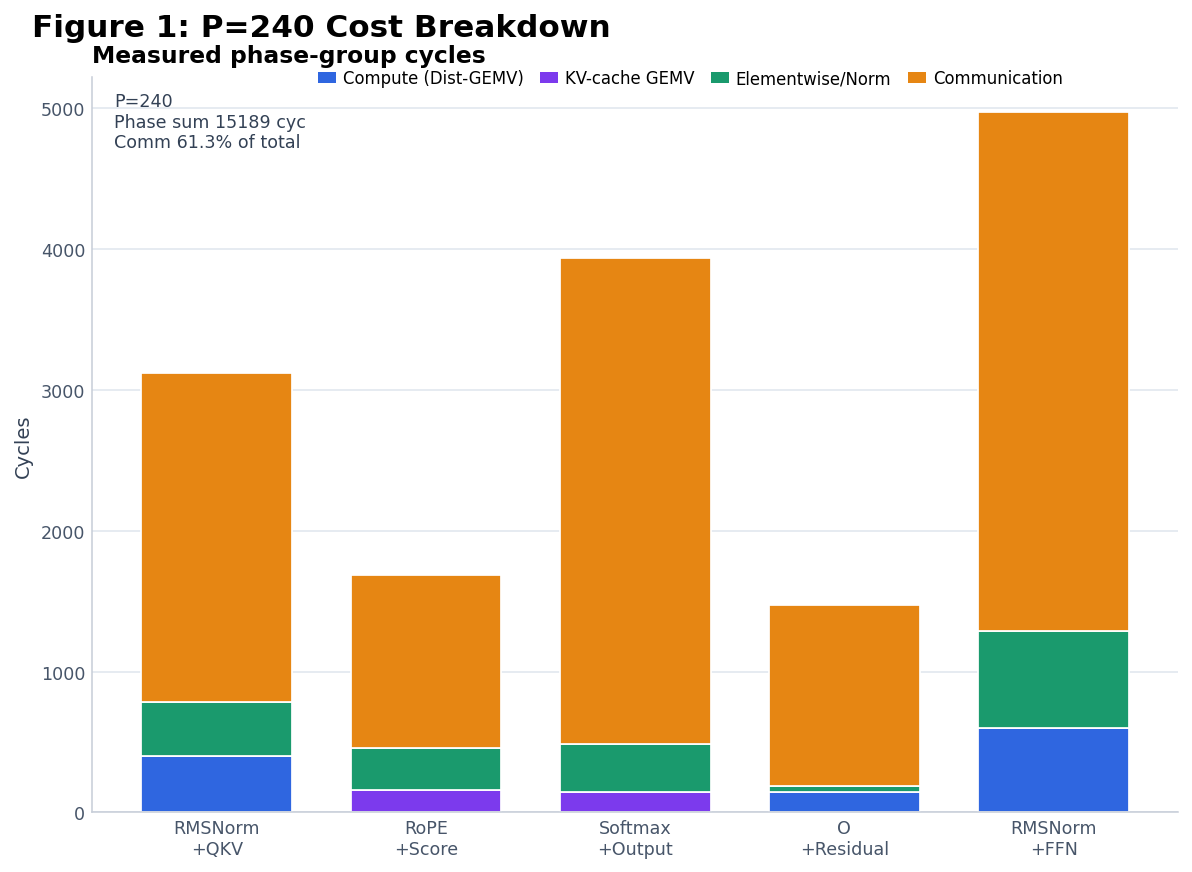

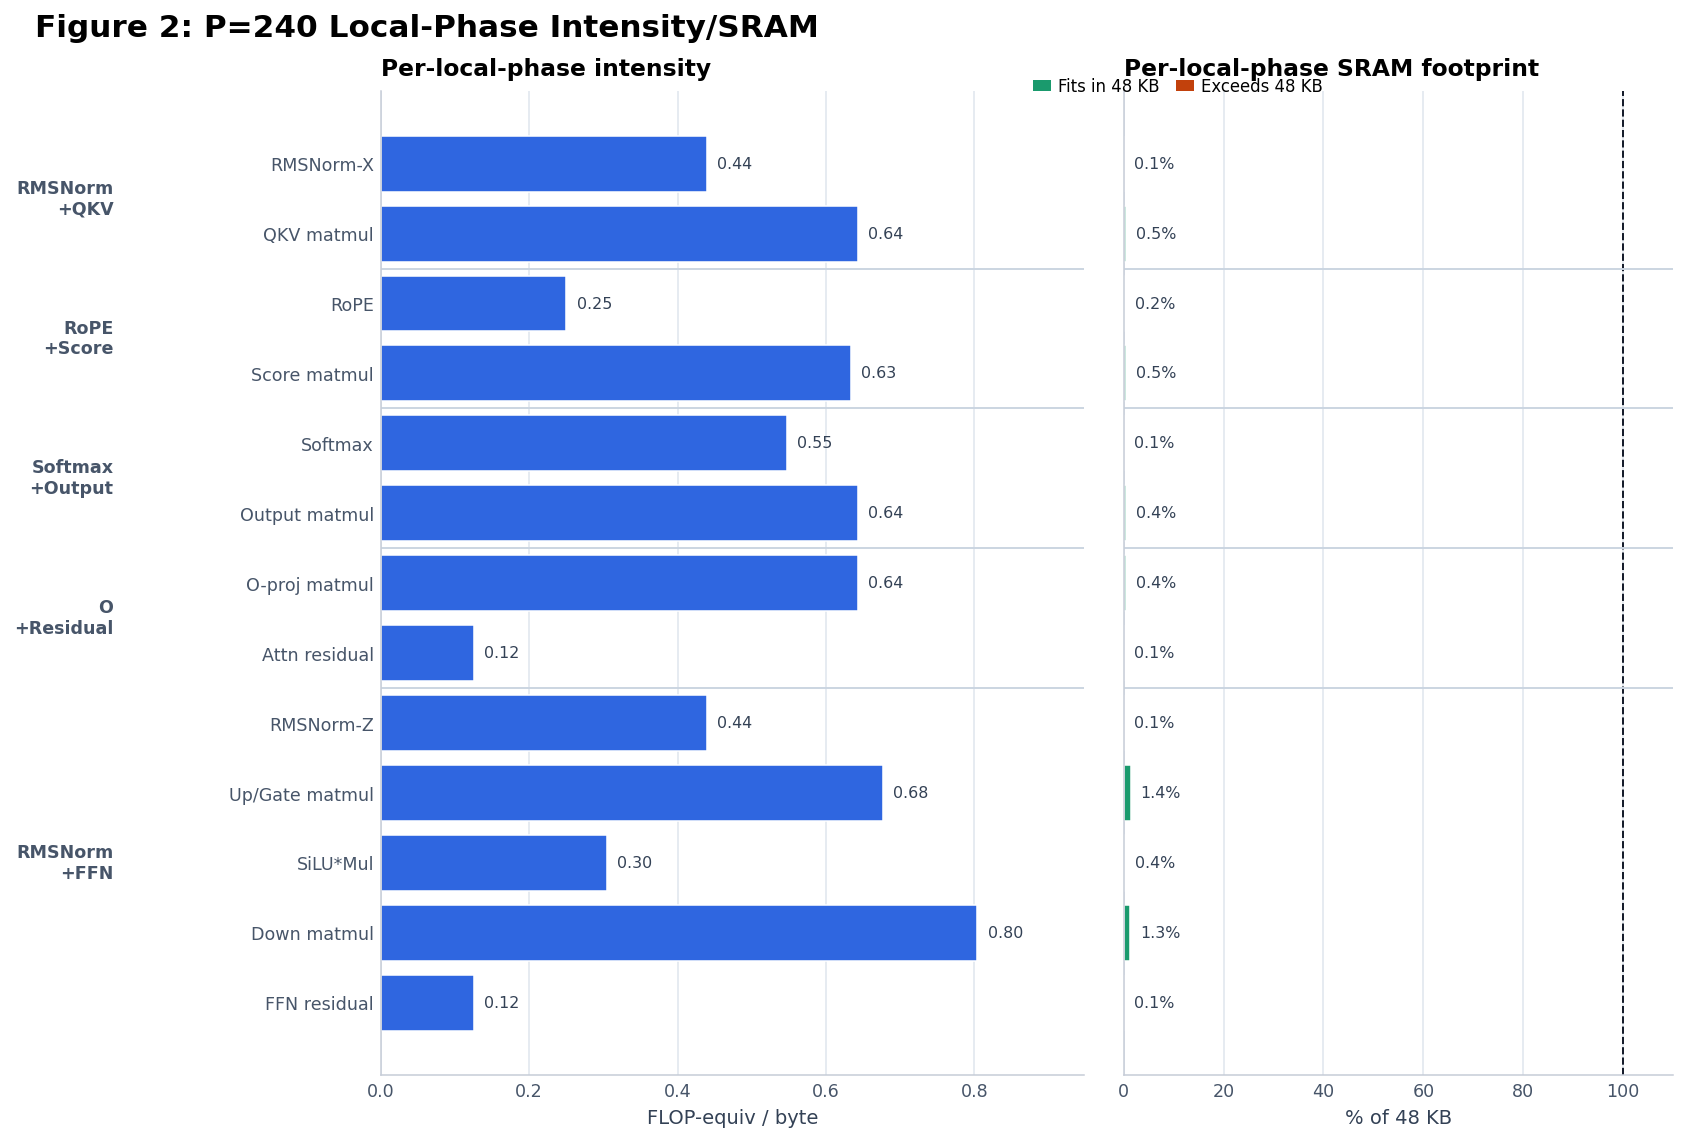

In [6]:
compact_cost_breakdown_figure(phase_group_category_df, overview_df)
compact_local_phase_figure(overview_df, phase_intensity_df)

## Figure 2

Each panel is one weak-scaling config. Each bar is one communication phase. The stack decomposes the original communication-phase total from `phase_summary.json`.

The blue and orange segments are the measured `Reduce` and `Broadcast` time from `comm_subphase_summary.json`. The gray segment is the residual communication-phase time not attributed to the instrumented reduce/broadcast subphases.

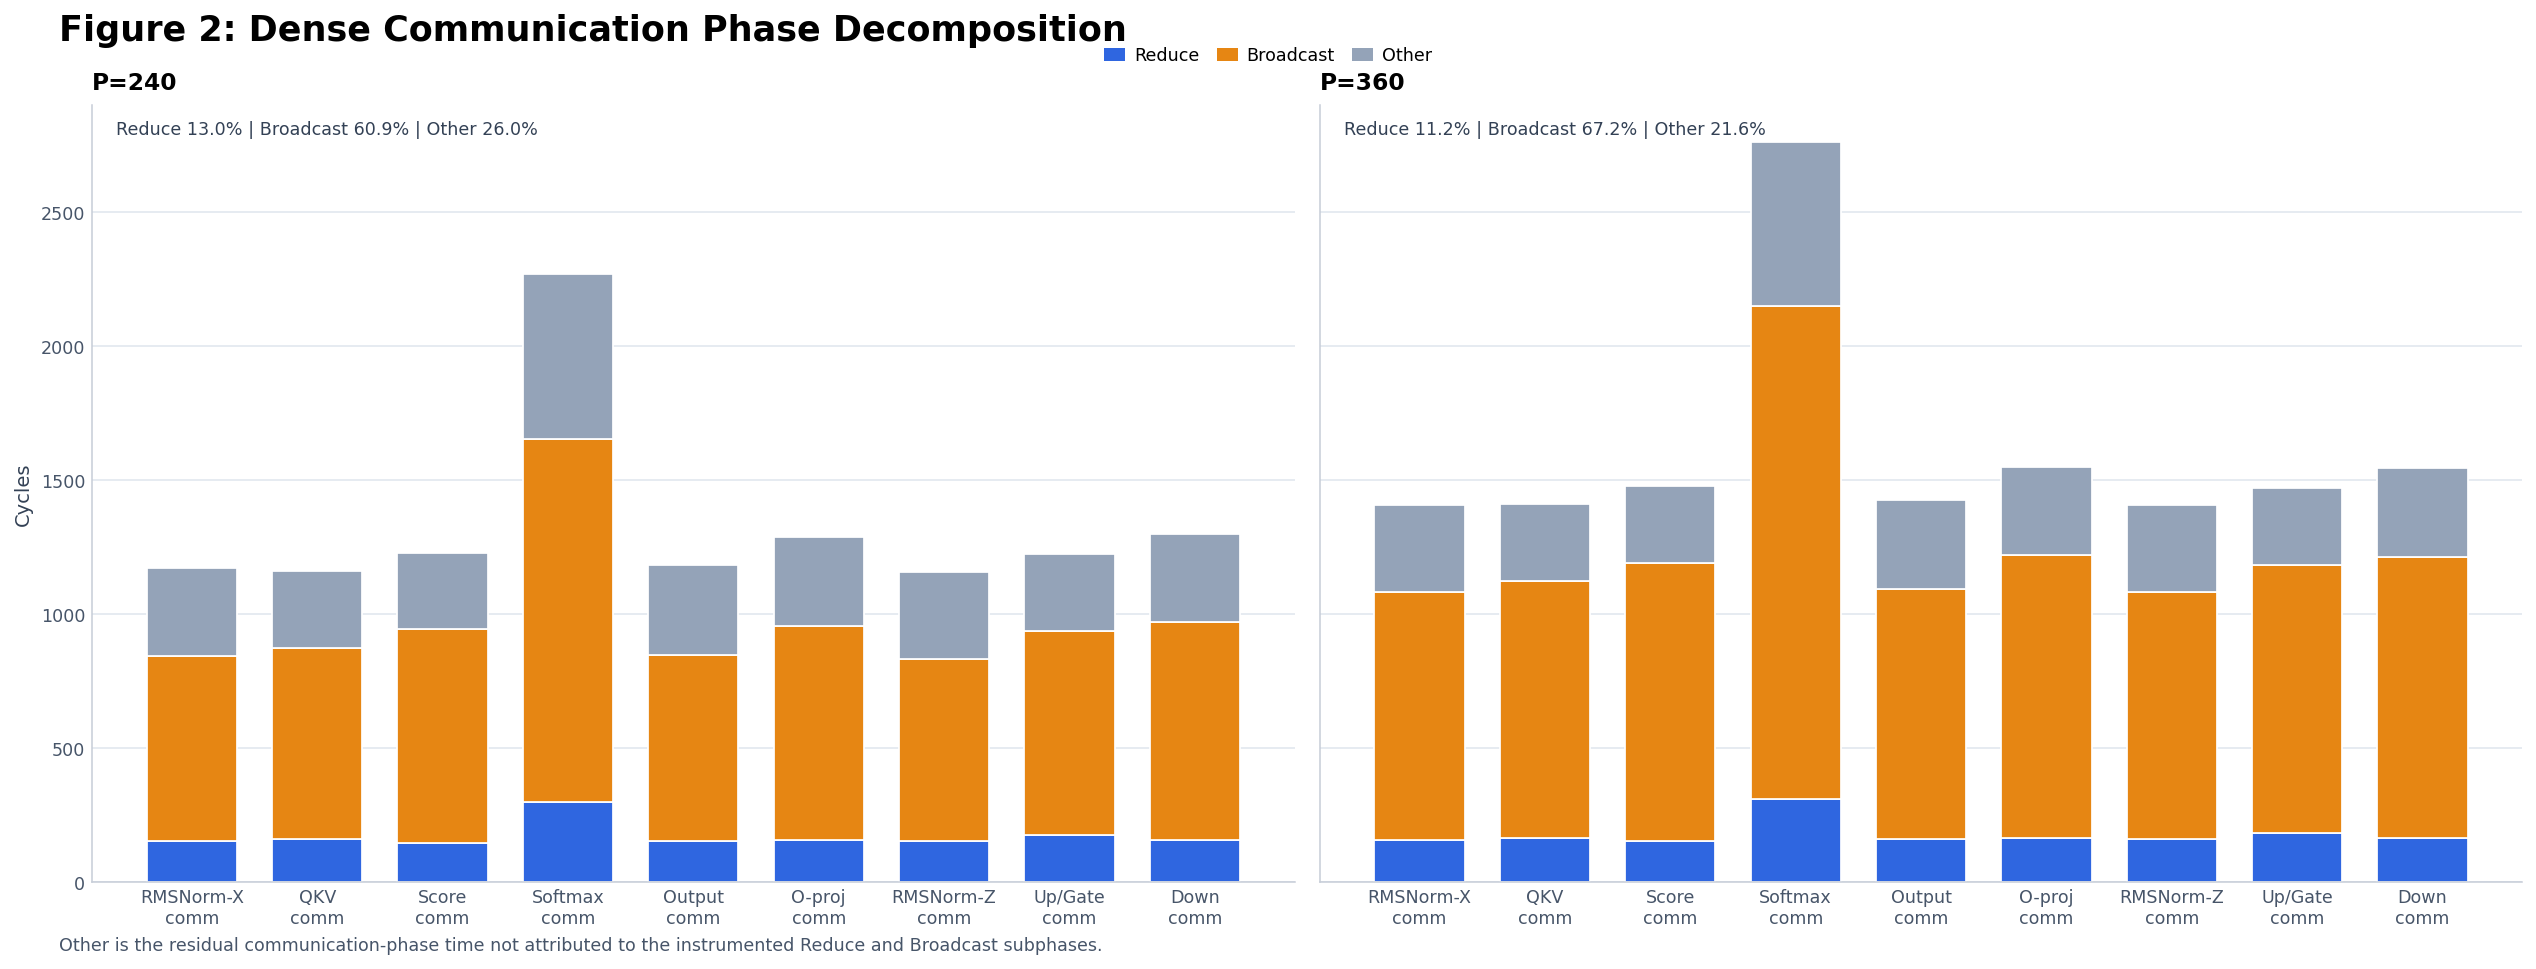

In [7]:
compact_comm_figure(comm_df, comm_subphase_df, axis_df)

## Support Table

This table keeps the non-visual metadata in one place: axis, collective API, reduction type, explicit collective-call count, payload expression, and the `QKV comm` interpretation. That removes the need for several extra figures.

In [8]:
support_df = comm_df[["phase_label", "axis", "api_impl", "reduction", "all_reduce_ops", "broadcast_ops", "payload_expr", "qkv_shift_check"]].drop_duplicates().reset_index(drop=True)
support_df

,phase_label,axis,api_impl,reduction,all_reduce_ops,broadcast_ops,payload_expr,qkv_shift_check
0,RMSNorm-X comm,Y-axis,all_reduce_bsz,sum,1,1,bsz,
1,QKV comm,Y-axis,all_reduce_bsz_dim_QKV_fusion,sum,1,1,bsz*3*dim_p_pe,"No: fused all-reduce of projected Q/K/V tiles,..."
2,Score comm,X-axis,all_reduce_bsz_seq_len,sum,1,1,bsz*seq_len_p_pe,
3,Softmax comm,Y-axis,all_reduceMax_bsz + all_reduce_bsz,max + sum,2,2,2*bsz,
4,Output comm,Y-axis,all_reduce_bsz_dim,sum,1,1,bsz*dim_p_pe,
5,O-proj comm,X-axis,all_reduce_bsz_dim,sum,1,1,bsz*dim_p_pe,
6,RMSNorm-Z comm,Y-axis,all_reduce_bsz,sum,1,1,bsz,
7,Up/Gate comm,Y-axis,all_reduce_bsz_ffn_dim_ZZ_fusion,sum,1,1,bsz*2*ffn_dim_p_pe,
8,Down comm,X-axis,all_reduce_bsz_dim,sum,1,1,bsz*dim_p_pe,


## QKV Note

`QKV comm` is a **Y-axis fused all-reduce** over projected `Q/K/V` tiles (`all_reduce_bsz_dim_QKV_fusion`). It is **not** KV-cache movement and **not** a shift primitive.